# 12: The Closest Thing We Have

Outlier reference notebook. It separates published facts, local reproduction of the rule/seed dynamics, and the causal test idea that motivates Chapter 13.


In [1]:
from pathlib import Path
import base64
import copy
import math
import sqlite3
from collections import Counter, defaultdict, deque
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
OUTLIER_MAP = (
    "ERETQB4eHWkQ7xD4eYZosBQZFixOBHmtFeehExrKVhURLRAq"
    "GxeIlSO1JYZP6DRi69rop7TQCkvWTIag7kAS8g"
)
SEED = np.array([[0,1,0],[1,1,1],[0,0,1]], dtype=np.uint8)
OFFSETS = [(-1,-1,256),(-1,0,128),(-1,1,64),(0,-1,32),(0,0,16),(0,1,8),(1,-1,4),(1,0,2),(1,1,1)]

def decode_map_rule(encoded):
    padding = "=" * ((4 - len(encoded) % 4) % 4)
    raw = base64.b64decode(encoded + padding)
    bits = np.unpackbits(np.frombuffer(raw, dtype=np.uint8))
    if bits.size < 512:
        raise ValueError(f"MAP rule has only {bits.size} bits")
    return bits[:512].astype(np.uint8)

def index_to_grid(index):
    return np.array([(index >> shift) & 1 for shift in range(8, -1, -1)], dtype=np.uint8).reshape(3, 3)

def grid_to_index(grid):
    value = 0
    for bit in grid.reshape(-1):
        value = (value << 1) | int(bit)
    return value

def verify_rotational_symmetry(rule):
    for index in range(512):
        grid = index_to_grid(index)
        expected = int(rule[index])
        rotated = grid.copy()
        for _ in range(3):
            rotated = np.rot90(rotated)
            assert int(rule[grid_to_index(rotated)]) == expected

def make_world(size):
    world = np.zeros((size, size), dtype=np.uint8)
    r = size // 2 - 1
    c = size // 2 - 1
    world[r:r+3, c:c+3] = SEED
    return world

def neighborhood_codes(state):
    code = np.zeros(state.shape, dtype=np.uint16)
    for dr, dc, weight in OFFSETS:
        shifted = np.roll(np.roll(state, -dr, axis=0), -dc, axis=1)
        code |= shifted.astype(np.uint16) * np.uint16(weight)
    return code

def outlier_step(state, rule):
    return rule[neighborhood_codes(state)]


In [3]:
EXPERIMENT = {"teaching_size": 160, "teaching_generations": 160, "capture_times": [0, 2, 10, 40, 80, 160], "boundary": "periodic"}
EXPERIMENT


{'teaching_size': 160,
 'teaching_generations': 160,
 'capture_times': [0, 2, 10, 40, 80, 160],
 'boundary': 'periodic'}

## Decode and verify the published MAP rule


In [4]:
RULE = decode_map_rule(OUTLIER_MAP)
assert RULE.shape == (512,)
assert int(RULE.sum()) == 220
assert 512 - int(RULE.sum()) == 292
verify_rotational_symmetry(RULE)
{"neighborhood_cases": 2**9, "rule_entries": int(RULE.size), "live_outputs": int(RULE.sum()), "dead_outputs": int(512 - RULE.sum()), "rotational_symmetry": "verified"}


{'neighborhood_cases': 512,
 'rule_entries': 512,
 'live_outputs': 220,
 'dead_outputs': 292,
 'rotational_symmetry': 'verified'}

## Local reproduction: run the published seed in a smaller teaching world


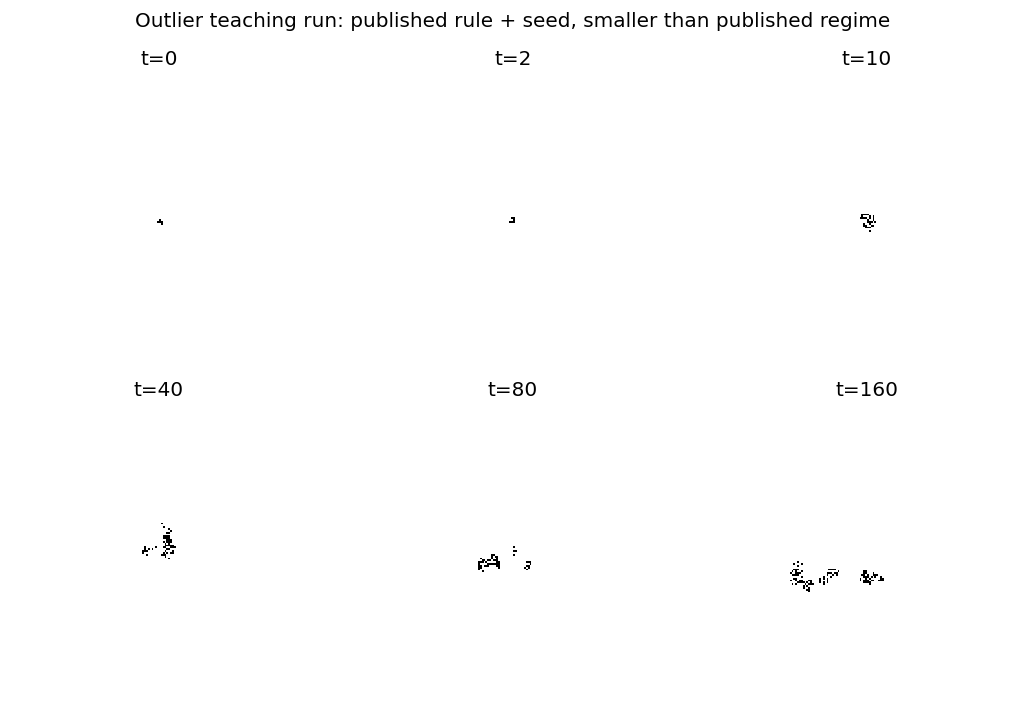

{'initial_live': 5, 'final_live': 106}

In [5]:
state = make_world(EXPERIMENT["teaching_size"]); frames={0: state.copy()}; population=[int(state.sum())]
for t in range(1, EXPERIMENT["teaching_generations"] + 1):
    state = outlier_step(state, RULE); population.append(int(state.sum()))
    if t in EXPERIMENT["capture_times"]: frames[t]=state.copy()
fig, axes = plt.subplots(2,3,figsize=(9,6));
for ax,t in zip(axes.flat, EXPERIMENT["capture_times"]):
    ax.imshow(frames[t], cmap="binary", interpolation="nearest", vmin=0, vmax=1); ax.set_title(f"t={t}"); ax.axis("off")
fig.suptitle("Outlier teaching run: published rule + seed, smaller than published regime"); fig.tight_layout(); fig.savefig(FIG_DIR / "ch12-outlier-teaching-snapshots.png", bbox_inches="tight"); plt.show()
{"initial_live": population[0], "final_live": population[-1]}


## Core counterfactual cell-level ancestry test


In [6]:
def child_dependencies(before, row, col, rule):
    code = int(neighborhood_codes(before)[row, col]); observed = int(rule[code]); deps=[]
    for dr, dc, weight in OFFSETS:
        pr=(row+dr) % before.shape[0]; pc=(col+dc) % before.shape[1]
        if before[pr, pc] == 1 and observed == 1:
            if int(rule[code ^ weight]) == 0: deps.append((pr, pc, weight))
    return observed, deps
before = make_world(16); after = outlier_step(before, RULE); live_child = tuple(np.argwhere(after == 1)[0])
observed, deps = child_dependencies(before, live_child[0], live_child[1], RULE)
{"child": live_child, "child_alive": observed, "necessary_live_predecessors": deps}


{'child': (np.int64(7), np.int64(7)),
 'child_alive': 1,
 'necessary_live_predecessors': [(np.int64(8), np.int64(7), 2),
  (np.int64(8), np.int64(8), 1)]}

## Bounded conclusion

The notebook verifies the published rule encoding facts and runs a local teaching reproduction of Outlier dynamics. The small run is not the full published regime. The causal mechanism is shown on one cell so Chapter 13's graph-level ancestry claim is understandable.

## Provenance

**Book chapter**: `content/books/digital-life/12-the-closest-thing-we-have/index.md`

**Research scripts used**: `ch10_outlier.py`, `ch10_outlier_lineage.py`

**Book figures reproduced**: notebook creates a teaching snapshot figure; checked-in Outlier GIFs/snapshots are not overwritten.
